In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/content/태림_통합데이터3.csv")

In [ ]:
df.head()

,ZF_PN,Supplier_PN,Order,ID_Release,Month,Year,Day,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY
0,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240314572,1.656.750
1,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240329575,1.656.750
2,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240405576,1.656.750
3,A0028219,A0028219,PO348384,20240521-004,April,2024,19,4.8,pc,FIRM,SEA,ZFB240419580,1.656.750
4,A0028219,A0028219,PO348384,20240521-004,April,2024,25,8.0,pc,FIRM,SEA,ZFB240412578,1.656.750


In [ ]:
df.isnull().sum()

,0
ZF_PN,0
Supplier_PN,0
Order,0
ID_Release,0
Month,0
Year,0
Day,0
Quantity,0
UN,0
Firm/Forecast,0


In [ ]:
df['Shipped_Invoice'].isna().sum()
df['Shipped_Invoice'].isna().mean()

np.float64(0.9019463473974006)

In [7]:
df['ZF_PN'].nunique()
df['Supplier_PN'].nunique()

6

In [8]:
df = df.drop(columns=['Supplier_PN'])

- ZF_PN → 유지, Supplier_PN → 제거

In [9]:
df.head()

,ZF_PN,Order,ID_Release,Month,Year,Day,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY
0,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240314572,1.656.750
1,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240329575,1.656.750
2,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240405576,1.656.750
3,A0028219,PO348384,20240521-004,April,2024,19,4.8,pc,FIRM,SEA,ZFB240419580,1.656.750
4,A0028219,PO348384,20240521-004,April,2024,25,8.0,pc,FIRM,SEA,ZFB240412578,1.656.750


In [10]:
df['Order'].nunique()

5

In [11]:
df["date"] = pd.to_datetime(
    df["Year"].astype(str) + " " + df["Month"] + " " + df["Day"].astype(str)
).dt.strftime("%Y%m%d")

In [13]:
df = df.drop(columns=['Month','Year','Day'])

In [14]:
df.head()

,ZF_PN,Order,ID_Release,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY,date
0,A0028219,PO348384,20240521-004,6.4,pc,FIRM,SEA,ZFB240314572,1.656.750,20240404
1,A0028219,PO348384,20240521-004,6.4,pc,FIRM,SEA,ZFB240329575,1.656.750,20240404
2,A0028219,PO348384,20240521-004,6.4,pc,FIRM,SEA,ZFB240405576,1.656.750,20240404
3,A0028219,PO348384,20240521-004,4.8,pc,FIRM,SEA,ZFB240419580,1.656.750,20240419
4,A0028219,PO348384,20240521-004,8.0,pc,FIRM,SEA,ZFB240412578,1.656.750,20240425


In [15]:
df["release_no"] = df["ID_Release"].str.split("-").str[1]
df["release_no"].value_counts()

,count
release_no,
004,30102
011,408
016,238
003,213
002,142
015,135


In [21]:
df = df.drop(columns=['UN'])

In [22]:
df

,ZF_PN,Order,ID_Release,Quantity,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY,date
0,A0028219,PO348384,20240521-004,6.400,FIRM,SEA,ZFB240314572,1.656.750,20240404
1,A0028219,PO348384,20240521-004,6.400,FIRM,SEA,ZFB240329575,1.656.750,20240404
2,A0028219,PO348384,20240521-004,6.400,FIRM,SEA,ZFB240405576,1.656.750,20240404
3,A0028219,PO348384,20240521-004,4.800,FIRM,SEA,ZFB240419580,1.656.750,20240419
4,A0028219,PO348384,20240521-004,8.000,FIRM,SEA,ZFB240412578,1.656.750,20240425
...,...,...,...,...,...,...,...,...,...
31233,A021N565,PO432429,20251110-004,3.024,FORECAST,SEA,NaN,163.632,20260928
31234,A021N565,PO432429,20251110-004,3.024,FORECAST,SEA,NaN,163.632,20261019
31235,A021N565,PO432429,20251110-004,2.688,FORECAST,SEA,NaN,163.632,20261026
31236,A021N565,PO432429,20251110-004,3.024,FORECAST,SEA,NaN,163.632,20261102


In [23]:
df["Shipping_Inst"].value_counts()

,count
Shipping_Inst,
SEA,31237
AIR,1


In [32]:
df["release_date"] = df["ID_Release"].str[:8]
df["release_no"] = df["ID_Release"].str.split("-").str[1]
df = df.drop(columns=["ID_Release"])

KeyError: 'ID_Release'

In [33]:
df

,ZF_PN,Order,Quantity,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY,date,release_doc_date,release_seq,release_date,release_no
0,A0028219,PO348384,6.400,FIRM,SEA,ZFB240314572,1.656.750,20240404,2024-05-21,004,20240521,004
1,A0028219,PO348384,6.400,FIRM,SEA,ZFB240329575,1.656.750,20240404,2024-05-21,004,20240521,004
2,A0028219,PO348384,6.400,FIRM,SEA,ZFB240405576,1.656.750,20240404,2024-05-21,004,20240521,004
3,A0028219,PO348384,4.800,FIRM,SEA,ZFB240419580,1.656.750,20240419,2024-05-21,004,20240521,004
4,A0028219,PO348384,8.000,FIRM,SEA,ZFB240412578,1.656.750,20240425,2024-05-21,004,20240521,004
...,...,...,...,...,...,...,...,...,...,...,...,...
31233,A021N565,PO432429,3.024,FORECAST,SEA,NaN,163.632,20260928,2025-11-10,004,20251110,004
31234,A021N565,PO432429,3.024,FORECAST,SEA,NaN,163.632,20261019,2025-11-10,004,20251110,004
31235,A021N565,PO432429,2.688,FORECAST,SEA,NaN,163.632,20261026,2025-11-10,004,20251110,004
31236,A021N565,PO432429,3.024,FORECAST,SEA,NaN,163.632,20261102,2025-11-10,004,20251110,004


- release_doc_date: 2024-05-21에 납품 스케줄 문서가 생성됨

In [34]:
df = df.drop(columns=["release_seq"])

In [35]:
df.head()

,ZF_PN,Order,Quantity,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY,date,release_doc_date,release_date,release_no
0,A0028219,PO348384,6.4,FIRM,SEA,ZFB240314572,1.656.750,20240404,2024-05-21,20240521,004
1,A0028219,PO348384,6.4,FIRM,SEA,ZFB240329575,1.656.750,20240404,2024-05-21,20240521,004
2,A0028219,PO348384,6.4,FIRM,SEA,ZFB240405576,1.656.750,20240404,2024-05-21,20240521,004
3,A0028219,PO348384,4.8,FIRM,SEA,ZFB240419580,1.656.750,20240419,2024-05-21,20240521,004
4,A0028219,PO348384,8.0,FIRM,SEA,ZFB240412578,1.656.750,20240425,2024-05-21,20240521,004


- ID_Release 변수에서 release 문서 생성 날짜를 추출하여 새로운 변수(release_date)를 생성

In [37]:
pd.crosstab(df["Firm/Forecast"], df["Shipped_Invoice"].isna())

Shipped_Invoice,False,True
Firm/Forecast,,
FIRM,3063,1324
FORECAST,0,26851


In [38]:
(df["release_doc_date"] - pd.to_datetime(df["date"], format="%Y%m%d")).dt.days.describe()

,0
count,31238.000000
mean,-228.922914
std,172.686338
min,-665.000000
25%,-359.000000
50%,-224.000000
75%,-88.000000
max,390.000000


In [39]:
df[df["Firm/Forecast"]=="FORECAST"].head()

,ZF_PN,Order,Quantity,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY,date,release_doc_date,release_date,release_no
9,A0028219,PO348384,6.4,FORECAST,SEA,NaN,1.656.750,20240626,2024-05-21,20240521,004
10,A0028219,PO348384,6.4,FORECAST,SEA,NaN,1.656.750,20240704,2024-05-21,20240521,004
11,A0028219,PO348384,6.4,FORECAST,SEA,NaN,1.656.750,20240712,2024-05-21,20240521,004
12,A0028219,PO348384,6.4,FORECAST,SEA,NaN,1.656.750,20240722,2024-05-21,20240521,004
13,A0028219,PO348384,6.4,FORECAST,SEA,NaN,1.656.750,20240730,2024-05-21,20240521,004


In [43]:
df["arrival_date"] = pd.to_datetime(df["date"], format="%Y%m%d") + pd.Timedelta(days=60)

- 브라질 수출의 경우 해상 운송 시간이 약 60일이므로, 출하 날짜(date)기준으로 60일을 더하여 예상 도착 날짜(arrival_date)를 생성

In [44]:
df.head()

,ZF_PN,Order,Quantity,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY,date,release_doc_date,release_date,release_no,arrival_date
0,A0028219,PO348384,6.4,FIRM,SEA,ZFB240314572,1.656.750,20240404,2024-05-21,20240521,004,2024-06-03
1,A0028219,PO348384,6.4,FIRM,SEA,ZFB240329575,1.656.750,20240404,2024-05-21,20240521,004,2024-06-03
2,A0028219,PO348384,6.4,FIRM,SEA,ZFB240405576,1.656.750,20240404,2024-05-21,20240521,004,2024-06-03
3,A0028219,PO348384,4.8,FIRM,SEA,ZFB240419580,1.656.750,20240419,2024-05-21,20240521,004,2024-06-18
4,A0028219,PO348384,8.0,FIRM,SEA,ZFB240412578,1.656.750,20240425,2024-05-21,20240521,004,2024-06-24


In [69]:
(df["arrival_date"] > df["release_doc_date"]).value_counts()


,count
True,30783
False,455


In [48]:
((df["arrival_date"] > df["release_doc_date"]).mean()) * 100

np.float64(98.5434406812216)

- 브라질 도착 날짜가 release 문서 생성 날짜보다 이후인지 확인 후 검증한 결과 98%의 신뢰도를 가지고 결과 나옴

In [49]:
df.groupby("arrival_date")["Quantity"].sum()

,Quantity
arrival_date,
2024-02-11,26.928
2024-06-03,68.432
2024-06-04,68.432
2024-06-17,51.744
2024-06-18,41.872
...,...
2027-07-11,17.088
2027-07-12,40.448
2027-07-13,1801.600


- 출하 날짜 기준으로 납품 수량 집계

In [50]:
df.groupby("date")["Quantity"].sum()

,Quantity
date,
20231213,26.928
20240404,68.432
20240405,68.432
20240418,51.744
20240419,41.872
...,...
20270512,17.088
20270513,40.448
20270514,1801.600


In [51]:
df.groupby(["date","Firm/Forecast"])["Quantity"].sum()

,,Quantity
date,Firm/Forecast,
20231213,FIRM,26.928
20240404,FIRM,68.432
20240405,FIRM,68.432
20240418,FIRM,51.744
20240419,FIRM,41.872
...,...,...
20270512,FORECAST,17.088
20270513,FORECAST,40.448
20270514,FORECAST,1801.600


In [55]:
df["CUM_QTY"].nunique()

222

In [56]:
df.sort_values("date")[["date","Quantity","CUM_QTY"]].head(20)

,date,Quantity,CUM_QTY
13160,20231213,1.680,587.531
12842,20231213,4.800,1.810.350
12929,20231213,3.200,833.64
12975,20231213,4.480,950.08
13066,20231213,2.688,955.996
13258,20231213,10.080,39.312
137,20240404,8.064,793.28
138,20240404,8.064,793.28
217,20240404,3.696,850.828
218,20240404,1.008,850.828


In [58]:
df["CUM_QTY"] = df["CUM_QTY"].str.replace(".", "", regex=False).astype(float)

In [59]:
(df["CUM_QTY"].diff() < 0).sum()

np.int64(266)

In [61]:
(df.sort_values("date")
   .groupby("ZF_PN")["CUM_QTY"]
   .diff()
   .lt(0)
    .sum())

np.int64(13877)

In [62]:
(
    df.sort_values(["ZF_PN", "Order", "date"])
      .groupby(["ZF_PN", "Order"])["CUM_QTY"]
      .diff()
      .lt(0)
      .sum()
)

np.int64(3214)

In [65]:
df["Shipping_Inst"].value_counts()

,count
Shipping_Inst,
SEA,31237
AIR,1


- air은 무시해도 되는 부분이지 않을까 생각

In [66]:
df["Quantity"].describe()
df["Quantity"].nunique()

65

<Axes: xlabel='date'>

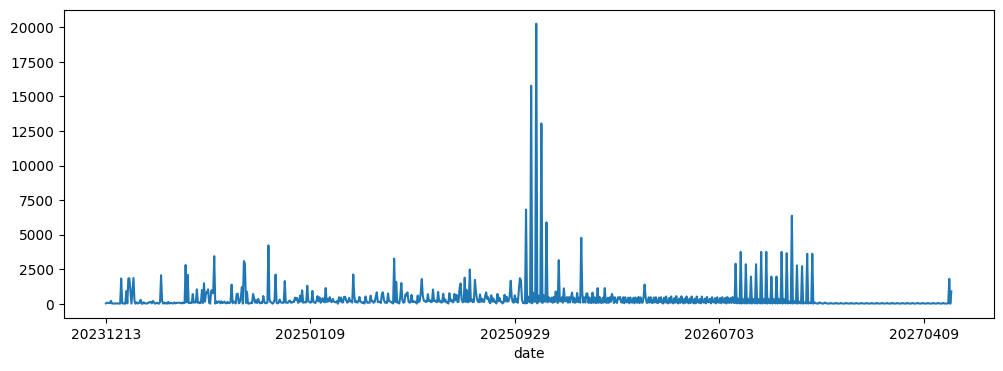

In [67]:
df.groupby("date")["Quantity"].sum().plot(figsize=(12,4))

- 날짜별 출하 수량(Quantity)을 시각화하여 수요 패턴과 변동성 확인 가능
- Quantity가 시간에 따라 변하는 수요 변수임을 확인 -> 이거 종속 변수로 써도 되지 않을까 생각

- | 상태       | 의미       |
  | -------- | -------- |
  | FORECAST | 미래 수요 계획 |
  | FIRM     | 확정 주문    |


- 출하가 발생한 경우에만 값 존재 -> FIRM 있을 때만 존재
- 출하가 없는 경우는 결측치로 빠짐


- 결국 부품 출하 수량을 예측을 하는데 어떠한 반식으로 수량을 예측하는지 봐야 할거 같고 lag 써서 며칠 단위로 예측을 해야 할지 실험이 필요할듯.